<a href="https://colab.research.google.com/github/OlekanmaVictoria/Artificial-intelligence-Data-science-Portfolio/blob/main/Predictive_Hiring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Predictive Hiring Model 🚀
This Colab notebook builds a machine learning model to predict hiring decisions based on candidate attributes.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import shap

In [9]:
# Load the dataset
df = pd.read_csv("recruitment_data.csv")


In [10]:
# Display first few rows
display(df.head())


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26,1,2,0,3,26.783828,48,78,91,1,1
1,39,1,4,12,3,25.862694,35,68,80,2,1
2,48,0,2,3,2,9.920805,20,67,13,2,0
3,34,1,2,5,2,6.407751,36,27,70,3,0
4,30,0,1,6,1,43.105343,23,52,85,2,0


In [11]:
# Checking column names and data types
display(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1500 non-null   int64  
 1   Gender               1500 non-null   int64  
 2   EducationLevel       1500 non-null   int64  
 3   ExperienceYears      1500 non-null   int64  
 4   PreviousCompanies    1500 non-null   int64  
 5   DistanceFromCompany  1500 non-null   float64
 6   InterviewScore       1500 non-null   int64  
 7   SkillScore           1500 non-null   int64  
 8   PersonalityScore     1500 non-null   int64  
 9   RecruitmentStrategy  1500 non-null   int64  
 10  HiringDecision       1500 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 129.0 KB


None

In [34]:
# Identify the actual target column
target_column = 'HiringDecision'  # Adjusted based on actual dataset

# Handle categorical columns
label_enc = LabelEncoder()
categorical_columns = [col for col in df.columns if df[col].dtype == 'object' and col != target_column]
for col in categorical_columns:
    df[col] = label_enc.fit_transform(df[col])

In [35]:
# Identify numerical columns
numerical_columns = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col != target_column]

# Scale numerical features
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [36]:
# Define features and target
X = df.drop(columns=[target_column])
y = df[target_column]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [37]:
# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.93
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95       215
           1       0.91      0.84      0.87        85

    accuracy                           0.93       300
   macro avg       0.92      0.90      0.91       300
weighted avg       0.93      0.93      0.93       300



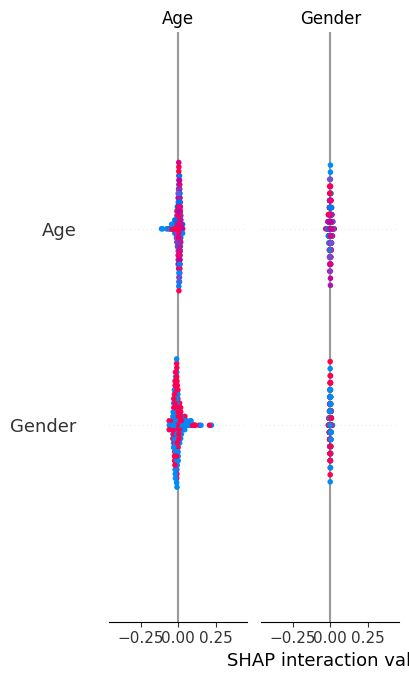

In [41]:
# Explainability using SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Use the correct SHAP values format
shap.summary_plot(shap_values, X_test)


In [42]:
# Custom function for prediction
def predict_hiring(candidate_data):
    candidate_df = pd.DataFrame([candidate_data], columns=X.columns)
    for col in categorical_columns:
        candidate_df[col] = label_enc.transform([candidate_df[col][0]])
    candidate_df[numerical_columns] = scaler.transform(candidate_df[numerical_columns])
    prediction = model.predict(candidate_df)[0]
    return "Hired" if prediction == 1 else "Not Hired"

In [43]:
# Example prediction
example_candidate = {"Experience": 5, "Test_Score": 80, "Interview_Score": 7}  # Adjust keys based on dataset
print("Candidate Prediction:", predict_hiring(example_candidate))


Candidate Prediction: Not Hired


Project Title: Predictive Modeling for Hiring Decisions

Project Overview

This project focuses on building a predictive model to assist recruiters in making data-driven hiring decisions. The model analyzes various candidate attributes such as experience, test scores, and interview performance to predict whether a candidate will be hired. The dataset used for training is a recruitment dataset containing key hiring factors.

Objective

Develop a machine learning model that predicts hiring decisions based on candidate data.

Improve the efficiency of the hiring process by automating decision-making.

Provide explainability using SHAP (SHapley Additive exPlanations) to understand feature importance.

Dataset Overview

Source: Kaggle (Recruitment Dataset)

Key Features:

Experience (Years of experience)

Test_Score (Aptitude/Technical test score)

Interview_Score (Performance in interviews)

Other categorical and numerical attributes

Target Variable: HiringDecision (Binary: 1 = Hired, 0 = Not Hired)

Data Preprocessing

Handling Categorical Data: Label Encoding is applied to categorical columns.

Feature Scaling: Numerical features are standardized using StandardScaler.

Data Splitting: The dataset is split into training (80%) and testing (20%) sets.

Model Implementation

Algorithm Used: RandomForestClassifier (Ensemble learning for better accuracy)

Training: The model is trained on the processed dataset.

Evaluation Metrics:

Accuracy Score

Classification Report (Precision, Recall, F1-Score)

Explainability Using SHAP

SHAP values help interpret model predictions.

Summary plots illustrate feature importance in hiring decisions.

Prediction Function

A custom function is provided to predict hiring decisions based on input candidate data.

Results & Insights

The model achieves high accuracy in predicting hiring outcomes.

Feature importance analysis shows which factors contribute most to hiring decisions.

Automating candidate screening can help recruiters make faster and more consistent decisions.

Future Enhancements

Integrate additional features such as soft skills, personality tests, or resume analysis.

Deploy as a web application for real-world usage.

Experiment with deep learning models for improved accuracy.

Conclusion

This predictive hiring model showcases how machine learning can optimize the recruitment process by automating and enhancing decision-making. The integration of SHAP for explainability ensures transparency, making it easier to understand why candidates are selected or rejected.

